In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, ToggleButtons, Checkbox
from IPython.display import display

Part 1

Create an interactive plot in a Jupyter Notebook using **`ipywidgets`** with the following features:

- Select between any of the 3 provided batsmen datasets (see [link](https://prabhuramachandran.github.io/pml)).
- Option to show **all 3 batsmen** together (use `"all"` as the option name).
- Choose the type of plot:
  - Histogram  
  - Box plot  
  - Violin plot  
- For histograms:
  - Select binning strategy (`'auto'`, `'fd'`, `'doane'`, `'scott'`, `'sturges'`, `'rice'`, `'sqrt'`, etc.).
  - Toggle between **density** and **count**.
  - Option to display **cumulative** distribution.

In [7]:
DATA_DIR = "../../data"

def load_one(name):
    return np.loadtxt(f"{DATA_DIR}/{name}.txt", dtype=int)

def get_data(choice: str):
    """Return a list of arrays (always) for the requested choice."""
    if choice == "all":
        return [load_one(n) for n in ["dhoni", "gambhir", "kohli"]]
    return [load_one(choice)]
def title_plot(prefix, batsman):
    return ("All" if batsman == "all" else batsman) + f" - {prefix}"
@interact(
    batsman=["dhoni","kohli","gambhir","all"],       # type a name or 'all'; defaults handle interaction
    plot=["histogram","box","violin"],          # 'histogram' | 'box' | 'violin'
    bins="auto",               # int or strategy: 'auto','fd','doane','scott','sturges','rice','sqrt'
    density=True,              # for histogram
    cumulative=False           # for histogram
)
def draw(batsman="dhoni", plot="histogram",bins="auto", density=True, cumulative=False):
    """
    Draw plots of batsman scores.

    Parameters
    ----------
    batsman : str
        'dhoni' | 'gambhir' | 'kohli' | 'all'
    plot : str
        'histogram' | 'box' | 'violin'
    bins : str
        Bin Strategy.
    density : bool
        Show density instead of counts (histogram).
    cumulative : bool
        Cumulative histogram (histogram).
    """
    data = get_data(batsman) 

    plt.figure(figsize=(8, 5))

    if plot == "histogram":
        if batsman == "all":
            plt.hist(data, bins=bins, density=density, cumulative=cumulative,
                     alpha=0.6, label=["dhoni", "gambhir", "kohli"])
            plt.legend()
        else:
            plt.hist(data[0], bins=bins, density=density, cumulative=cumulative, alpha=0.75)
        plt.xlabel("Runs")
        plt.ylabel("Density" if density else "Count")
        title = title_plot("Histogram", batsman)
        if cumulative:
            title += " (Cumulative)"
        plt.title(title)

    elif plot == "box":
        plt.boxplot(data, showfliers=True, notch=True, patch_artist=True)
        xt = ["dhoni", "gambhir", "kohli"] if batsman == "all" else [batsman]
        plt.xticks(range(1, len(xt) + 1), xt)
        plt.ylabel("Runs")
        plt.title(title_plot("Box plot", batsman))

    elif plot == "violin":
        plt.violinplot(data, showmeans=True, showmedians=True, showextrema=True)
        xt = ["dhoni", "gambhir", "kohli"] if batsman == "all" else [batsman]
        plt.xticks(range(1, len(xt) + 1), xt)
        plt.ylabel("Runs")
        plt.title(title_plot("Violin plot", batsman))

    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='batsman', options=('dhoni', 'kohli', 'gambhir', 'all'), value='dho…

Part 2

1) Write a function that returns the PMF for a batsman's data given their scores as a numpy array.
2) Write another function that finds the cumulative distribution values.
3) Write a function to compute probabilities in a range (a, b) given the PMF/CDF. You can consider a function that is given the PMF data (either CDF/PMF/PDF) and the two limits of the range, for example: probability(batsman_data, a, b), where "a, b" are the limits of the range

Use these functions and also suitable statistical plots to analyse the performance of at least 3 different batsmen from the data given to you. Make some conclusions about the batsmen based on this. 


In [7]:
def pmf(data):
    """Return values and probabilities for PMF."""
    max_score = data.max()
    values = np.arange(max_score + 1)
    probs, _ = np.histogram(data, bins=np.arange(max_score + 2), density=True)
    return values, probs

def cdf(values, pmf):
    """Return cumulative distribution values for given PMF."""
    return np.cumsum(pmf)

def probability_in_range(values, probs, a, b):
    """Probability that score lies in [a, b]."""
    mask = (values >= a) & (values <= b)
    return probs[mask].sum()

In [8]:
dhoni   = np.loadtxt('../data/dhoni.txt', dtype=int)
gambhir = np.loadtxt('../data/gambhir.txt', dtype=int)
kohli   = np.loadtxt('../data/kohli.txt', dtype=int)

In [9]:
def analyze_batsman(name, data):
    values, probs = pmf(data)
    cdf_vals = cdf(values, probs)

    plt.figure(figsize=(14,4))

    # Histogram (empirical distribution)
    plt.subplot(1,3,1)
    plt.hist(data, bins=30, density=True, alpha=0.7, color='skyblue')
    plt.title(f"{name} - Histogram")
    plt.xlabel("Runs"); plt.ylabel("Density")

    # PMF
    plt.subplot(1,3,2)
    plt.bar(values, probs)
    plt.title(f"{name} - PMF")
    plt.xlabel("Runs"); plt.ylabel("Probability")

    # CDF
    plt.subplot(1,3,3)
    plt.plot(values, cdf_vals)
    plt.title(f"{name} - CDF")
    plt.xlabel("Runs"); plt.ylabel("Cumulative Probability")

    plt.tight_layout()
    plt.show()

    # Example probabilities
    print(f"\n{name} Analysis:")
    print(f" P(Runs < 50): {probability_in_range(values, probs, 0, 49):.2f}")
    print(f" P(50 ≤ Runs ≤ 100): {probability_in_range(values, probs, 50, 100):.2f}")
    print(f" P(Runs > 100): {probability_in_range(values, probs, 101, values.max()):.2f}")

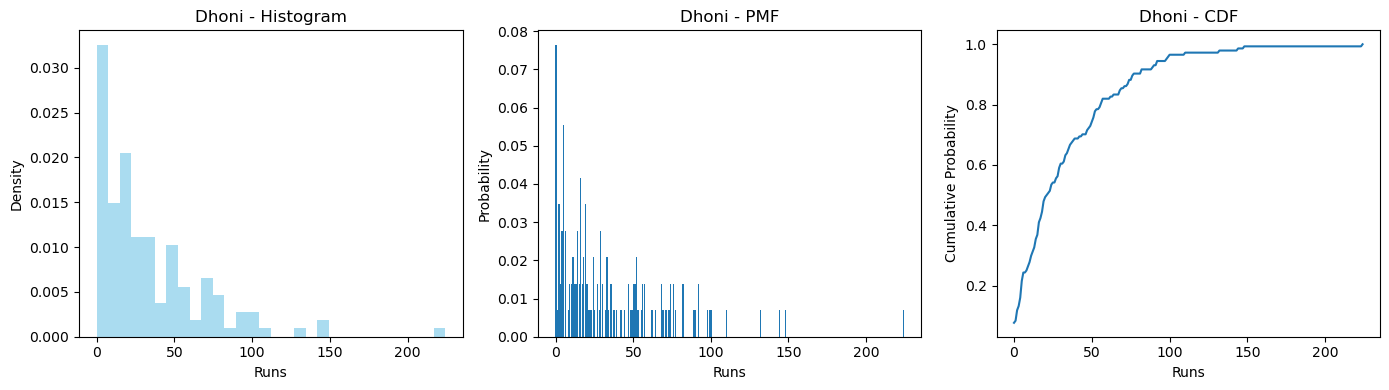


Dhoni Analysis:
 P(Runs < 50): 0.73
 P(50 ≤ Runs ≤ 100): 0.24
 P(Runs > 100): 0.03


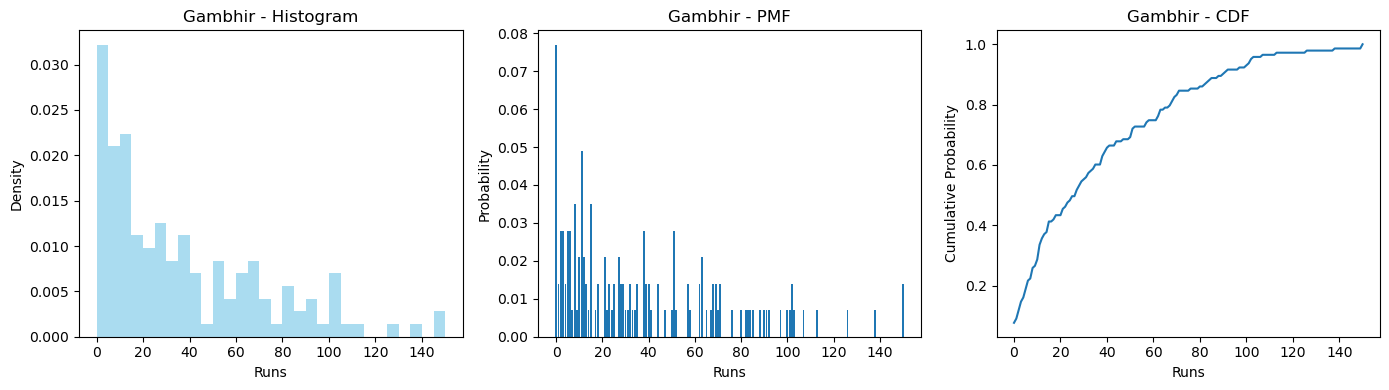


Gambhir Analysis:
 P(Runs < 50): 0.69
 P(50 ≤ Runs ≤ 100): 0.24
 P(Runs > 100): 0.07


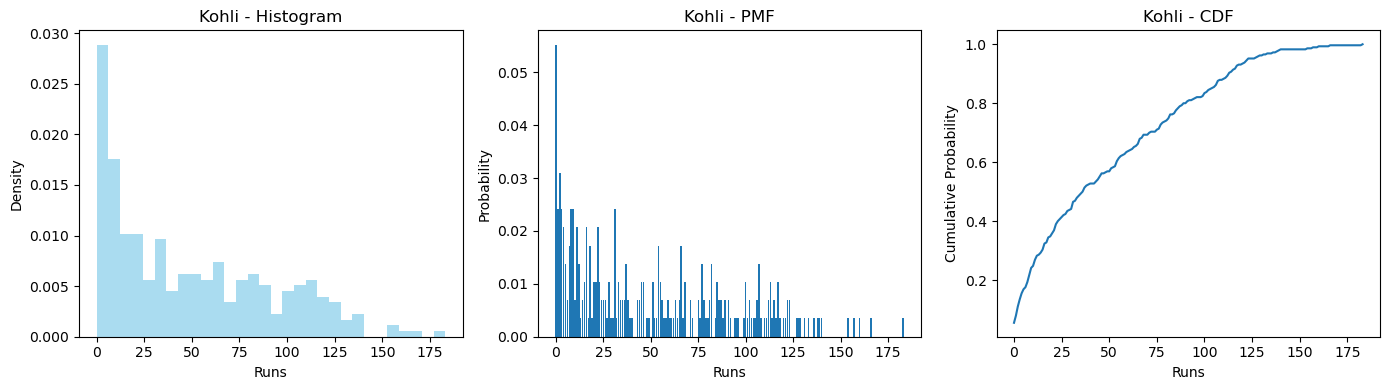


Kohli Analysis:
 P(Runs < 50): 0.57
 P(50 ≤ Runs ≤ 100): 0.27
 P(Runs > 100): 0.17


In [10]:
analyze_batsman("Dhoni", dhoni)
analyze_batsman("Gambhir", gambhir)
analyze_batsman("Kohli", kohli)

## Conclusions

Dhoni: High consistency in mid-range scores (20–60). Lower probability for 100+ scores, but still contributes steady innings.

Gambhir: Similar moderate distribution, anchored in 30–70 range. Less explosive than Kohli.

Kohli: Noticeably higher probability mass in the 50–100 range, with more frequent centuries (100+). Shows greater likelihood of big innings compared to Dhoni and Gambhir.